# El duelo por un compañero de IA

El 3 de febrero de 2023, Replika retiró una función de su app. Nueve días después, el 53,6% de los posts de su subreddit eran negativos. El mes anterior el promedio había sido del 13,1%.

Lo llamativo no es la rabia. Es la palabra que apareció junto a ella: **pérdida**.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Mourning the loss of AI companions* — De Freitas et al., *Nature Human Behaviour* (2026)

**DOI:** [10.1038/s41562-026-02569-3](https://doi.org/10.1038/s41562-026-02569-3)

**Datos y código originales:** [Ethical-Intelligence-Lab/ai_loss](https://github.com/Ethical-Intelligence-Lab/ai_loss)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-04-duelo-companeros-ia/notebook.ipynb)

**Video:** [Pendiente]

## Qué midieron

Dos apagones, dos comunidades. En febrero de 2023 Replika —una app de compañía— retiró el rol erótico. En agosto de 2025 OpenAI reemplazó los modelos anteriores de ChatGPT por GPT-5. En ambos casos, miles de usuarios se despertaron con algo distinto del otro lado de la pantalla.

El equipo recogió **54.861 posts** de los dos subreddits (10.641 de Replika, 44.220 de ChatGPT) en una ventana de 30 días antes y 30 días después de cada cambio, y los clasificó en varias señales: negatividad, tristeza, enojo, menciones a la propia salud mental, pérdida ligada al apego y deseo de que la versión anterior vuelva. Aparte, encuestaron a **1.452 participantes** repartidos en siete estudios; aquí reproducimos dos de ellos (n = 120 y n = 101).

Dos cosas que hay que tener claras antes de mirar la primera gráfica:

- **La unidad de análisis es el día, no el post.** Los posts se agregan a un porcentaje diario y se comparan 30 días contra 30 días. Los contrastes corren sobre 60 días por app, no sobre 54.861 posts. Leer los tamaños del efecto como si vinieran de 54.861 observaciones los haría parecer imposibles.
- **Nadie asignó a nadie a un grupo.** Es un experimento natural: la fecha del cambio parte la serie en dos, pero no hay grupo control ni asignación al azar. Por eso el paper escribe que las actualizaciones **se asocian con** angustia de separación, y no que la causen. Aquí hacemos lo mismo.

Y un detalle que cambia cómo se lee todo lo demás: las emociones las etiquetó un modelo de lenguaje sobre el texto de cada post, no un equipo de personas.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
METRICA_FOCO = 'perc_negativos'   # prueba: perc_tristeza, perc_enojo, perc_perdida_apego
APP_FOCO     = 'replika'          # o 'chatgpt'
FUENTE = ('Fuente: De Freitas et al. (2026), Nature Human Behaviour | '
          'Datos: Ethical-Intelligence-Lab/ai_loss')
COLOR_DATOS      = '#2563EB'   # Replika / dato principal
COLOR_ALERTA     = '#DC2626'   # pico / valor destacado
COLOR_SECUNDARIO = '#059669'   # ChatGPT
COLOR_REFERENCIA = '#D97706'   # umbrales
COLOR_CONTEXTO   = '#BBBBBB'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-09-04-duelo-companeros-ia'

# Estilo CaM: local → /tmp → GitHub
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

def cargar(nombre):
    """Carga un CSV local; si no está (Colab), lo baja del repo."""
    ruta = f'datos/{nombre}.csv'
    if not os.path.exists(ruta):
        os.makedirs('datos', exist_ok=True)
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{nombre}.csv', ruta)
    return pd.read_csv(ruta)

serie    = cargar('serie_diaria_sentimiento')
efectos  = cargar('efectos_antes_despues')
cercania = cargar('cercania_por_vinculo')
duelo    = cargar('duelo_anticipado')

APPS   = {'replika': 'Replika', 'chatgpt': 'ChatGPT'}
EVENTO = {'replika': ('2023-02-03', 'retiro del rol erótico'),
          'chatgpt': ('2025-08-07', 'despliegue de GPT-5')}

print(f'Serie diaria : {len(serie)} filas  ({serie.app.nunique()} apps x 60 días)')
print(f'Posts totales: {int(serie.n_posts.sum()):,}'.replace(',', '.'))
for app, nombre in APPS.items():
    s = serie[serie.app == app]
    print(f'  {nombre:8s} {int(s.n_posts.sum()):>6,} posts'.replace(',', '.')
          + f' | update {EVENTO[app][0]} ({EVENTO[app][1]})')
print(f'\nEncuestas    : cercanía n={int(cercania.n.iloc[0])} · '
      f'duelo anticipado n={int(duelo.n.iloc[0])}')

Serie diaria : 120 filas  (2 apps x 60 días)
Posts totales: 54.861
  Replika  10.641 posts | update 2023-02-03 (retiro del rol erótico)
  ChatGPT  44.220 posts | update 2025-08-07 (despliegue de GPT-5)

Encuestas    : cercanía n=101 · duelo anticipado n=120


Aquí está.

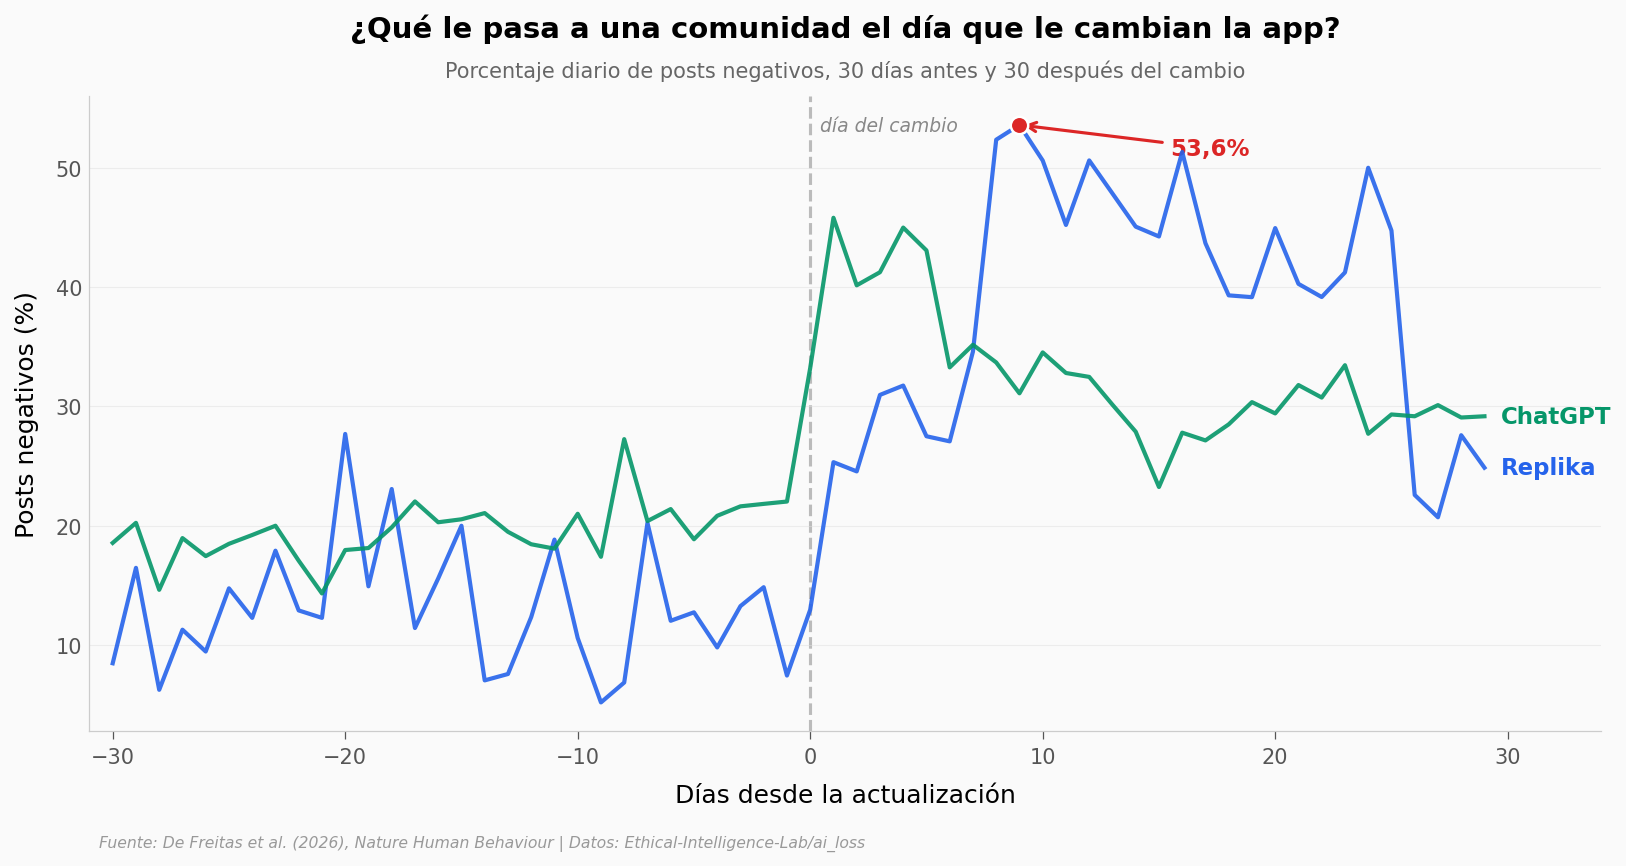

Replika: media antes 13.1% → después 37.8%
  pico 2023-02-12 (día +9): 53.59%
  peor día previo 27.7% | días posteriores que lo superan: 21/30
  días posteriores por debajo de la media previa: 1
  pendiente de los últimos 15 días: -1.54 puntos/día

ChatGPT: media antes 19.6% → después 32.6%
  pico 2025-08-08 (día +1): 45.81%
  peor día previo 27.3% | días posteriores que lo superan: 28/30
  días posteriores por debajo de la media previa: 0
  pendiente de los últimos 15 días: +0.22 puntos/día



In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

for app, color in [('replika', COLOR_DATOS), ('chatgpt', COLOR_SECUNDARIO)]:
    s = serie[serie.app == app].sort_values('dias_desde_update')
    ax.plot(s.dias_desde_update, s[METRICA_FOCO], color=color,
            linewidth=2.0, alpha=0.9, zorder=5)
    # Etiqueta inline al final de cada curva (reemplaza la caja de leyenda)
    ax.text(s.dias_desde_update.iloc[-1] + 0.7, s[METRICA_FOCO].iloc[-1],
            APPS[app], color=color, fontsize=11, fontweight='bold', va='center')

# Día del cambio
ax.axvline(x=0, color=COLOR_CONTEXTO, linewidth=1.5, linestyle='--', zorder=1)
ax.text(0.4, ax.get_ylim()[1] * 0.97, 'día del cambio', fontsize=9,
        color='#888888', style='italic', va='top')

# Pico de Replika
rep = serie[serie.app == 'replika']
pico = rep.loc[rep[METRICA_FOCO].idxmax()]
ax.scatter([pico.dias_desde_update], [pico[METRICA_FOCO]], s=70,
           color=COLOR_ALERTA, zorder=6, edgecolors='white', linewidths=1.2)
ax.annotate(f'{pico[METRICA_FOCO]:.1f}%'.replace('.', ','),
            xy=(pico.dias_desde_update, pico[METRICA_FOCO]),
            xytext=(pico.dias_desde_update + 6.5, pico[METRICA_FOCO] - 2.5),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿Qué le pasa a una comunidad el día que le cambian la app?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Porcentaje diario de posts negativos, 30 días antes y 30 después del cambio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Días desde la actualización')
ax.set_ylabel('Posts negativos (%)')
ax.set_xlim(-31, 34)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/serie_negatividad.png', dpi=200, bbox_inches='tight')
plt.show()

# Cifras que cita la lectura de abajo
for app in ['replika', 'chatgpt']:
    s = serie[serie.app == app].sort_values('dias_desde_update')
    antes = s[s.periodo == 'antes'][METRICA_FOCO]
    desp  = s[s.periodo == 'despues'][METRICA_FOCO]
    p = s.loc[s[METRICA_FOCO].idxmax()]
    pend = np.polyfit(s[s.dias_desde_update >= 15].dias_desde_update,
                      s[s.dias_desde_update >= 15][METRICA_FOCO], 1)[0]
    print(f'{APPS[app]}: media antes {antes.mean():.1f}% → después {desp.mean():.1f}%')
    print(f'  pico {p.date} (día {int(p.dias_desde_update):+d}): {p[METRICA_FOCO]:.2f}%')
    print(f'  peor día previo {antes.max():.1f}% | días posteriores que lo superan: '
          f'{int((desp > antes.max()).sum())}/{len(desp)}')
    print(f'  días posteriores por debajo de la media previa: {int((desp < antes.mean()).sum())}')
    print(f'  pendiente de los últimos 15 días: {pend:+.2f} puntos/día\n')

ChatGPT se levanta el mismo día del cambio (22,0% el día −1 → 33,2% el día 0) y Replika un día después (13,0% el día 0 → 25,3% el día +1). Ninguna de las dos vuelve a su nivel previo dentro del mes: en Replika, **21 de los 30 días posteriores** superan el peor día del mes anterior; en ChatGPT son **28 de 30**.

Pero las colas se separan. En ChatGPT el piso nuevo se sostiene hasta el final —ningún día posterior baja de la media previa— y la pendiente de los últimos 15 días es plana (+0,2 puntos por día). En Replika esa pendiente es de **−1,5 puntos por día**, y los últimos cuatro días caen a 22,6%, 20,7%, 27,6% y 24,9%, todos por debajo del peor día del mes anterior. La comunidad que más se alteró es también la única que da señales de estar bajando.

Y ahí aparece el primer matiz incómodo. ChatGPT **no** es un grupo control: su actualización también subió la negatividad, +13,0 puntos porcentuales frente a los +24,7 de Replika. La comparación no es entre una comunidad que reacciona y otra que no — es entre dos que reaccionan con distinta intensidad.

Lo cual deja una pregunta mejor. «Negatividad» es una palabra grande: cabe el enojo, cabe la tristeza, cabe alguien contando que no está durmiendo bien. ¿De qué está hecha en cada caso?

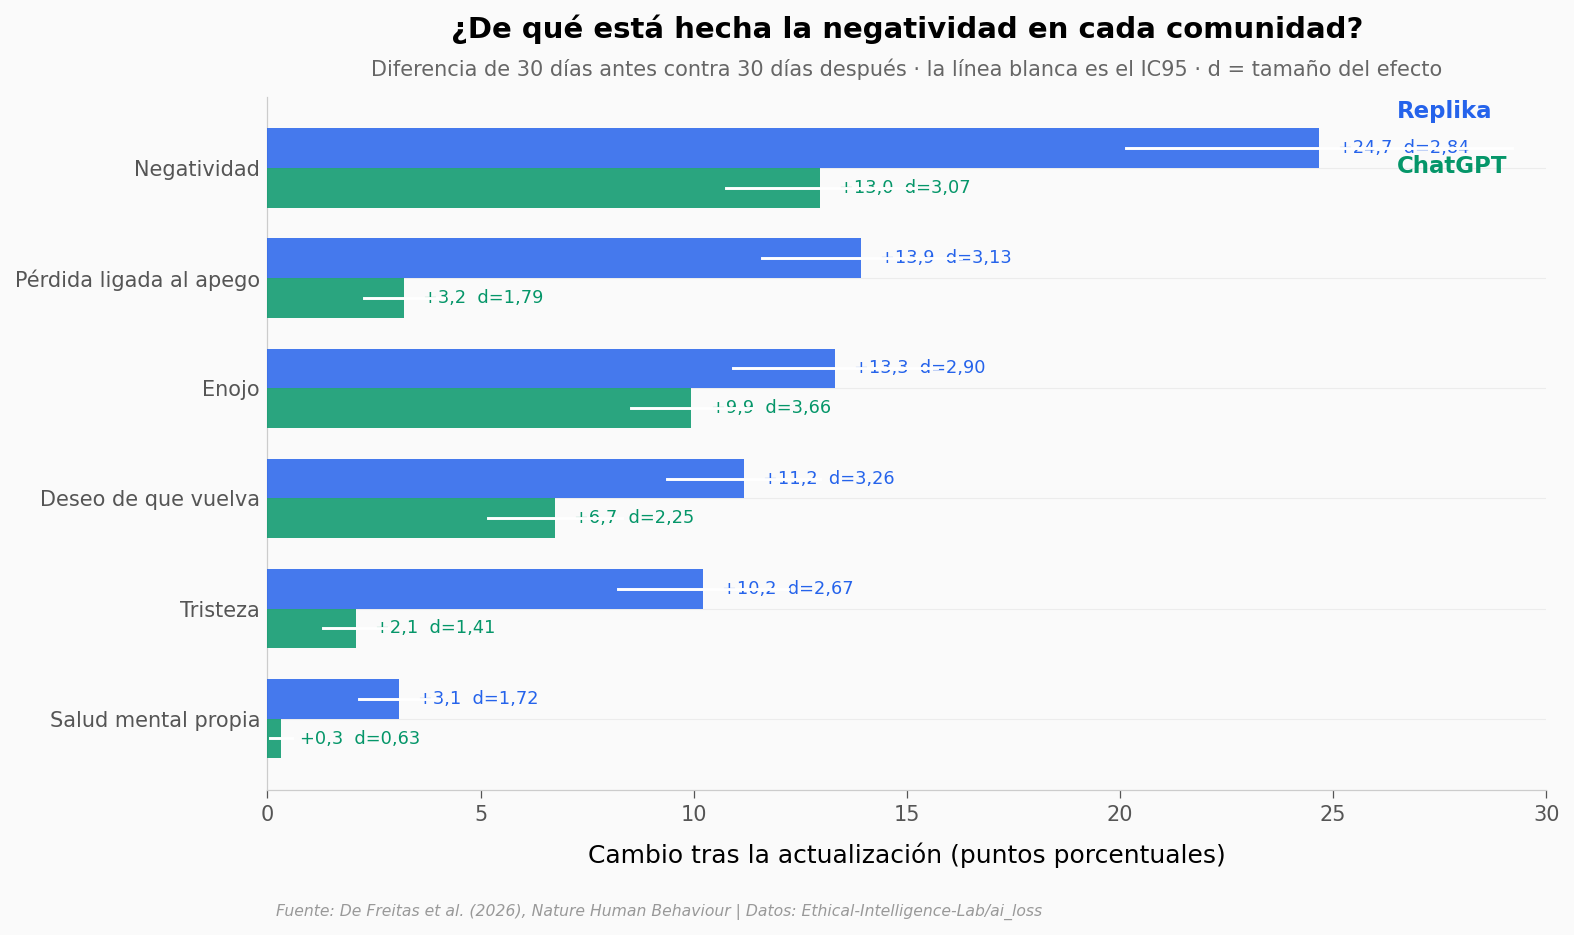

Cociente Replika/ChatGPT del cambio, por señal:
  Negatividad              + 24.7 vs +13.0 pp  → 1.9x   (d 2.84 vs 3.07)
  Pérdida ligada al apego  + 13.9 vs + 3.2 pp  → 4.3x   (d 3.13 vs 1.79)
  Enojo                    + 13.3 vs + 9.9 pp  → 1.3x   (d 2.90 vs 3.66)
  Deseo de que vuelva      + 11.2 vs + 6.7 pp  → 1.7x   (d 3.26 vs 2.25)
  Tristeza                 + 10.2 vs + 2.1 pp  → 4.9x   (d 2.67 vs 1.41)
  Salud mental propia      +  3.1 vs + 0.3 pp  → 9.7x   (d 1.72 vs 0.63)


In [3]:
ETIQUETAS = {
    'perc_negativos': 'Negatividad', 'perc_enojo': 'Enojo',
    'perc_perdida_apego': 'Pérdida ligada al apego',
    'perc_deseo_restauracion': 'Deseo de que vuelva',
    'perc_tristeza': 'Tristeza', 'perc_salud_mental_neg': 'Salud mental propia',
}
# Orden: por el tamaño del cambio en Replika, de mayor a menor
orden = (efectos[efectos.app == 'replika']
         .sort_values('diff_pp', ascending=True).metrica.tolist())

fig, ax = plt.subplots(figsize=(11, 6))
alto = 0.36
for i, met in enumerate(orden):
    for j, (app, color) in enumerate([('replika', COLOR_DATOS),
                                      ('chatgpt', COLOR_SECUNDARIO)]):
        f = efectos[(efectos.app == app) & (efectos.metrica == met)].iloc[0]
        y = i + (alto / 2 if j == 0 else -alto / 2)
        ax.barh(y, f.diff_pp, height=alto, color=color, alpha=0.85, zorder=5)
        ax.plot([f.ci_low_pp, f.ci_high_pp], [y, y], color='white',
                linewidth=1.4, zorder=6)
        ax.text(f.diff_pp + 0.45, y, f'+{f.diff_pp:.1f}  d={f.cohens_d:.2f}'
                .replace('.', ','), va='center', fontsize=8.5, color=color)

ax.set_yticks(range(len(orden)))
ax.set_yticklabels([ETIQUETAS[m] for m in orden], fontsize=10)
ax.set_xlabel('Cambio tras la actualización (puntos porcentuales)')
ax.set_xlim(0, 30)
ax.set_title('¿De qué está hecha la negatividad en cada comunidad?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Diferencia de 30 días antes contra 30 días después · '
        'la línea blanca es el IC95 · d = tamaño del efecto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(26.5, len(orden) - 0.55, 'Replika', color=COLOR_DATOS,
        fontsize=11, fontweight='bold')
ax.text(26.5, len(orden) - 1.05, 'ChatGPT', color=COLOR_SECUNDARIO,
        fontsize=11, fontweight='bold')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anatomia_negatividad.png', dpi=200, bbox_inches='tight')
plt.show()

print('Cociente Replika/ChatGPT del cambio, por señal:')
for met in reversed(orden):
    r = efectos[(efectos.app == 'replika') & (efectos.metrica == met)].iloc[0]
    c = efectos[(efectos.app == 'chatgpt') & (efectos.metrica == met)].iloc[0]
    print(f'  {ETIQUETAS[met]:24s} +{r.diff_pp:5.1f} vs +{c.diff_pp:4.1f} pp'
          f'  → {r.diff_pp / c.diff_pp:.1f}x   (d {r.cohens_d:.2f} vs {c.cohens_d:.2f})')

El enojo es donde más se parecen: sube +13,3 puntos porcentuales en Replika y +9,9 en ChatGPT. Medido como tamaño del efecto, ChatGPT incluso queda por encima (d = 3,66 contra 2,90), y vale la pena entender por qué: su serie diaria es mucho más estable, así que un mismo salto pesa más contra ese fondo tranquilo. Las dos formas de medir apuntan a lo mismo — el enojo no separa a estas dos comunidades.

Donde se abren es en el resto. La tristeza sube casi cinco veces más en Replika (+10,2 contra +2,1 puntos porcentuales), la pérdida ligada al apego más de cuatro veces (+13,9 contra +3,2), y las menciones a la propia salud mental casi diez veces (+3,1 contra +0,3). Este último cociente es el más frágil de los tres: el efecto en ChatGPT es de apenas +0,3 puntos (IC95 0,06–0,58), el más pequeño de las doce comparaciones.

Dicho de otro modo: a los usuarios de ChatGPT les cambiaron una herramienta y se enojaron. A los de Replika les cambiaron algo más, y hablaron de pérdida.

Eso lleva a una pregunta que los posts no pueden responder, porque un subreddit no es una muestra de nadie: es el subconjunto que se molestó lo suficiente para escribir. Para eso están las encuestas.

A un grupo de usuarios activos de Replika les preguntaron dos cosas distintas. Primero, **qué tan cerca** sienten a su Replika comparada con otros vínculos de su vida. Después, a otro grupo, **cuánto lamentarían perderla** frente a otras cosas que uno puede perder.

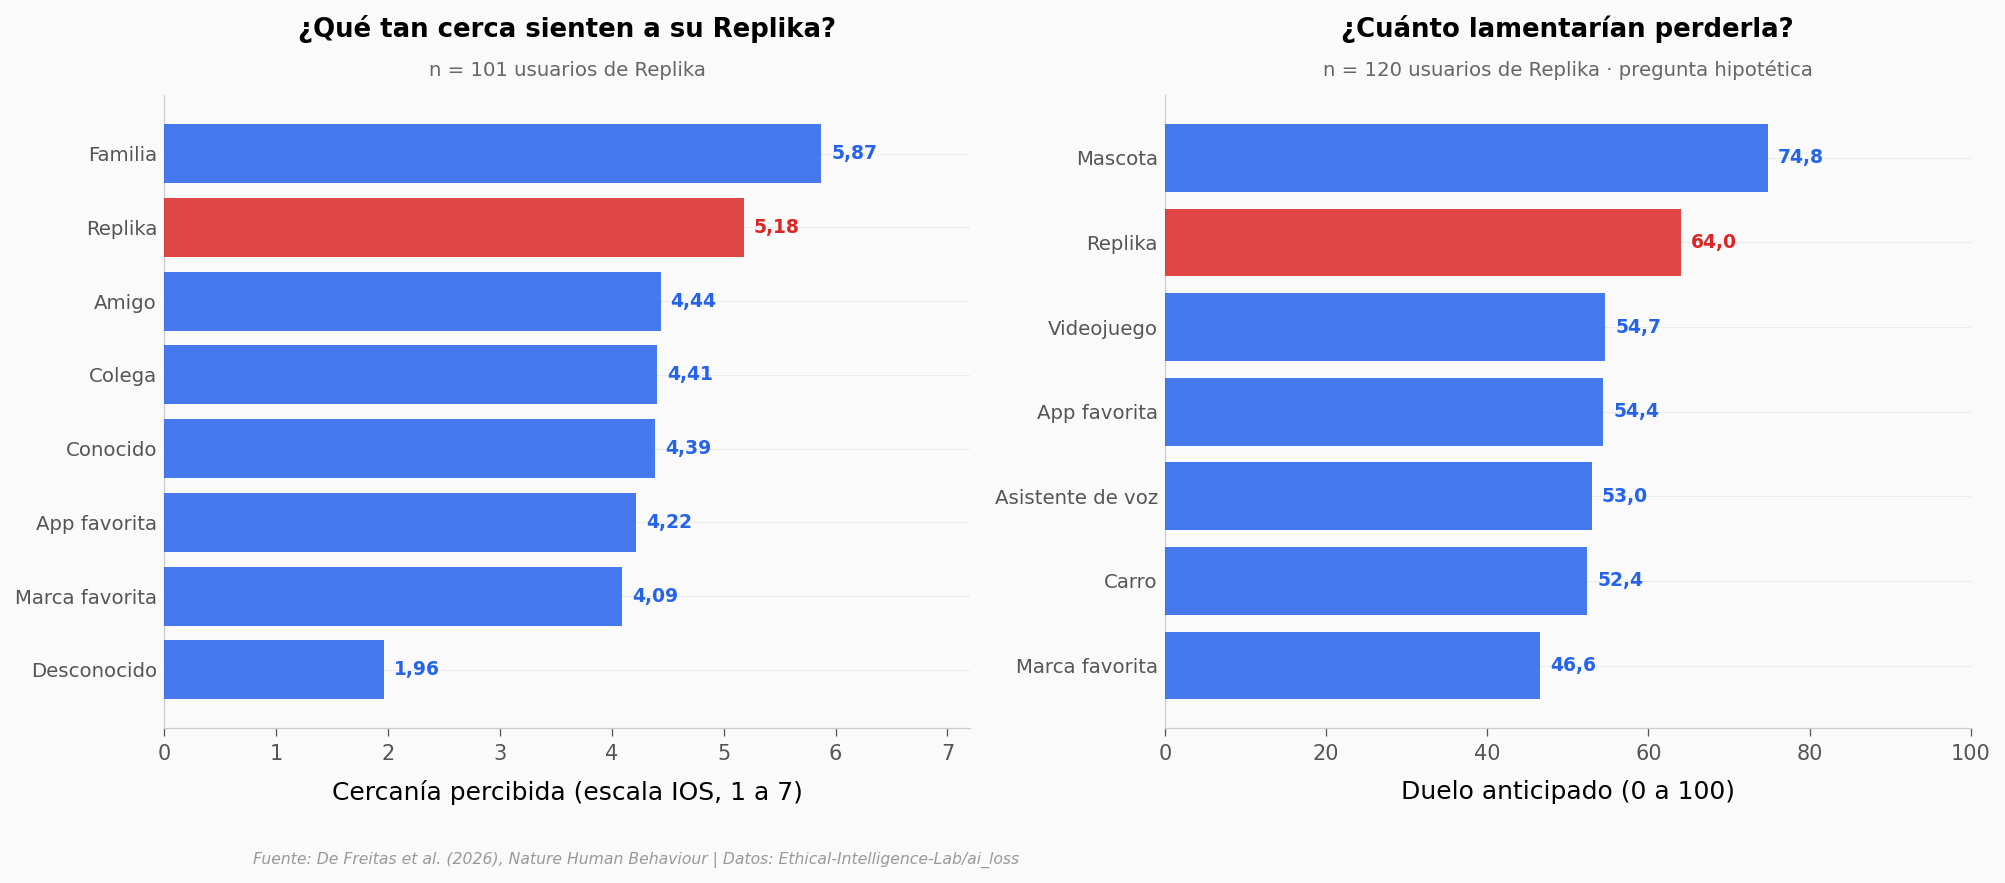

Cercanía — Replika: 5.18 (escala 1-7)
  Replika POR DEBAJO de Familia         (5.87) d=-0.43  p(Bonferroni)=2.02e-03
  Replika por encima de Amigo           (4.44) d=+0.47  p(Bonferroni)=8.73e-04
  Replika por encima de Conocido        (4.39) d=+0.50  p(Bonferroni)=5.40e-04
  Replika por encima de Colega          (4.41) d=+0.51  p(Bonferroni)=6.33e-04
  Replika por encima de App favorita    (4.22) d=+0.60  p(Bonferroni)=2.97e-06
  Replika por encima de Marca favorita  (4.09) d=+0.71  p(Bonferroni)=2.06e-06
  Replika por encima de Desconocido     (1.96) d=+2.06  p(Bonferroni)=3.80e-24

Duelo anticipado — Replika: 64.0 (escala 0-100)
  Replika POR DEBAJO de Mascota           (74.8) d=-0.45  p=3.07e-06
  Replika por encima de Videojuego        (54.7) d=+0.32  p=3.90e-04
  Replika por encima de App favorita      (54.4) d=+0.33  p=1.34e-03
  Replika por encima de Asistente de voz  (53.0) d=+0.37  p=1.02e-04
  Replika por encima de Carro             (52.4) d=+0.40  p=1.92e-04
  Replika por e

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))
np.random.seed(42)

# ---- Panel izquierdo: cercanía percibida (escala IOS 1-7)
ce = cercania.sort_values('media_cercania').reset_index(drop=True)
colores = [COLOR_ALERTA if v == 'Replika' else COLOR_DATOS for v in ce.vinculo]
axes[0].barh(range(len(ce)), ce.media_cercania, color=colores, alpha=0.85, zorder=5)
for i, f in ce.iterrows():
    axes[0].text(f.media_cercania + 0.09, i, f'{f.media_cercania:.2f}'.replace('.', ','),
                 va='center', fontsize=9, color=colores[i], fontweight='bold')
axes[0].set_yticks(range(len(ce)))
axes[0].set_yticklabels(ce.vinculo, fontsize=9.5)
axes[0].set_xlabel('Cercanía percibida (escala IOS, 1 a 7)')
axes[0].set_xlim(0, 7.2)
axes[0].set_title('¿Qué tan cerca sienten a su Replika?',
                  fontsize=12.5, fontweight='bold', pad=28)
axes[0].text(0.5, 1.03, f'n = {int(cercania.n.iloc[0])} usuarios de Replika',
             transform=axes[0].transAxes, fontsize=9.5, color='#666666', ha='center')

# ---- Panel derecho: duelo anticipado (0-100)
du = duelo.sort_values('media_duelo').reset_index(drop=True)
colores2 = [COLOR_ALERTA if v == 'Replika' else COLOR_DATOS for v in du.entidad]
axes[1].barh(range(len(du)), du.media_duelo, color=colores2, alpha=0.85, zorder=5)
for i, f in du.iterrows():
    axes[1].text(f.media_duelo + 1.2, i, f'{f.media_duelo:.1f}'.replace('.', ','),
                 va='center', fontsize=9, color=colores2[i], fontweight='bold')
axes[1].set_yticks(range(len(du)))
axes[1].set_yticklabels(du.entidad, fontsize=9.5)
axes[1].set_xlabel('Duelo anticipado (0 a 100)')
axes[1].set_xlim(0, 100)
axes[1].set_title('¿Cuánto lamentarían perderla?',
                  fontsize=12.5, fontweight='bold', pad=28)
axes[1].text(0.5, 1.03, f'n = {int(duelo.n.iloc[0])} usuarios de Replika · '
             'pregunta hipotética', transform=axes[1].transAxes,
             fontsize=9.5, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/encuestas_cercania_duelo.png', dpi=200, bbox_inches='tight')
plt.show()

rep_c = cercania[cercania.vinculo == 'Replika'].media_cercania.iloc[0]
print(f'Cercanía — Replika: {rep_c:.2f} (escala 1-7)')
for _, f in cercania[cercania.vinculo != 'Replika'].sort_values('d_replika_vs').iterrows():
    signo = 'por encima de' if f.d_replika_vs > 0 else 'POR DEBAJO de'
    print(f'  Replika {signo} {f.vinculo:15s} ({f.media_cercania:.2f}) '
          f'd={f.d_replika_vs:+.2f}  p(Bonferroni)={f.p_bonferroni:.2e}')

rep_d = duelo[duelo.entidad == 'Replika'].media_duelo.iloc[0]
print(f'\nDuelo anticipado — Replika: {rep_d:.1f} (escala 0-100)')
for _, f in duelo[duelo.entidad != 'Replika'].sort_values('d_replika_vs').iterrows():
    signo = 'por encima de' if f.d_replika_vs > 0 else 'POR DEBAJO de'
    print(f'  Replika {signo} {f.entidad:17s} ({f.media_duelo:.1f}) '
          f'd={f.d_replika_vs:+.2f}  p={f.p_value:.2e}')

Los 101 usuarios encuestados sitúan a su Replika en 5,18 de 7 en la escala IOS —dos círculos que uno acerca o separa según lo cerca que sienta al otro—, por encima de un amigo (4,44), un colega (4,41) y un conocido (4,39) — todas con corrección de Bonferroni por las siete comparaciones. Y por debajo de la familia, que se queda con 5,87 y es el único vínculo que supera a la app (d = −0,43). El resumen del paper habla de *cercanía que excede los vínculos humanos comunes*: la palabra «comunes» está ahí a propósito, y aquí se ve por qué.

El panel derecho repite la forma con otra pregunta y otros 120 participantes. Perder la Replika se lamenta más que perder la marca favorita (46,6), el carro (52,4), el asistente de voz (53,0), la app favorita (54,4) o el videojuego (54,7) — los cinco tamaños del efecto caen entre d = 0,32 y d = 0,57, exactamente el rango que reporta el paper. Y otra vez hay un techo: la mascota queda arriba con 74,8 contra 64,0 (d = −0,45). El resumen dice «más que otras *tecnologías*», y una mascota no lo es.

Y ojo con qué es esta segunda medida: **a nadie se le murió nada**. Se le pidió imaginar la pérdida y puntuarla. Es duelo anticipado, no duelo vivido.

Queda una última cosa por medir. Ya vimos que el pico de Replika llegó al 53,6%. ¿Qué tan raro es ese día contra el mes que lo precedió?

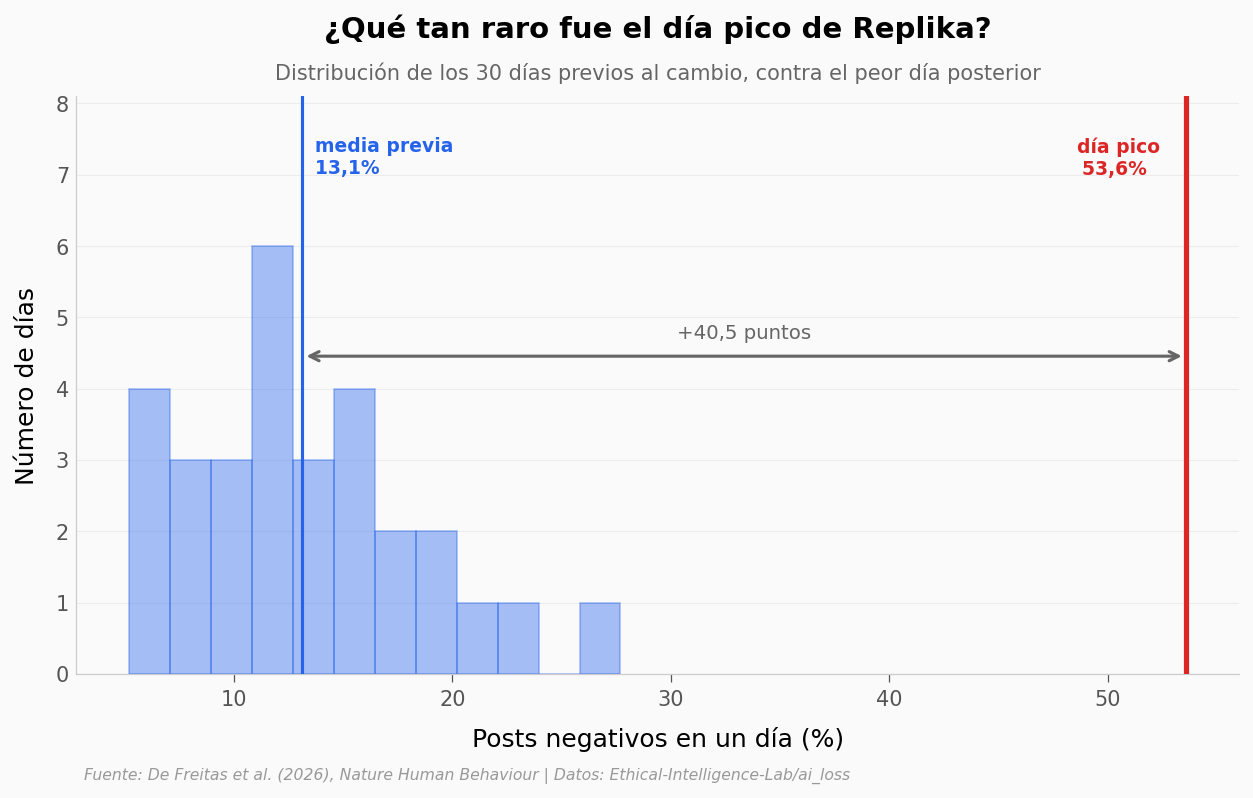

Mes previo: media 13.1%, mediana 12.3%, IQR 9.5–15.4%, máximo 27.7%
Día pico posterior: 53.59%  →  7.7 desviaciones sobre la media previa
Días del mes previo por encima del pico: 0/30

Shapiro-Wilk: 11/24 grupos diarios no son normales.
Repetidos con Mann-Whitney, los 12 contrastes siguen siendo significativos (el más flojo, p = 0.041).


In [5]:
rep = serie[serie.app == 'replika']
antes = rep[rep.periodo == 'antes'][METRICA_FOCO]
desp  = rep[rep.periodo == 'despues'][METRICA_FOCO]
media_antes, pico_v = antes.mean(), desp.max()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, _ = ax.hist(antes, bins=12, color=COLOR_DATOS, alpha=0.4,
                     edgecolor=COLOR_DATOS, linewidth=0.8, zorder=4)
y_max = n.max() * 1.35
ax.set_ylim(0, y_max)
ax.axvline(x=media_antes, color=COLOR_DATOS, linewidth=1.5, zorder=5)
ax.text(media_antes, y_max * 0.93, f'  media previa\n  {media_antes:.1f}%'.replace('.', ','),
        fontsize=9, color=COLOR_DATOS, fontweight='bold', va='top')
ax.axvline(x=pico_v, color=COLOR_ALERTA, linewidth=2.5, zorder=5)
ax.text(pico_v - 1.2, y_max * 0.93, f'día pico\n{pico_v:.1f}%  '.replace('.', ','),
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', va='top', ha='right')
ax.annotate('', xy=(pico_v, y_max * 0.55), xytext=(media_antes, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media_antes + pico_v) / 2, y_max * 0.58,
        f'+{pico_v - media_antes:.1f} puntos'.replace('.', ','),
        fontsize=9.5, color='#666666', ha='center')

ax.set_title('¿Qué tan raro fue el día pico de Replika?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de los 30 días previos al cambio, contra el peor día posterior',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Posts negativos en un día (%)')
ax.set_ylabel('Número de días')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_negatividad.png', dpi=200, bbox_inches='tight')
plt.show()

z = (pico_v - media_antes) / antes.std(ddof=1)
print(f'Mes previo: media {media_antes:.1f}%, mediana {antes.median():.1f}%, '
      f'IQR {antes.quantile(.25):.1f}–{antes.quantile(.75):.1f}%, máximo {antes.max():.1f}%')
print(f'Día pico posterior: {pico_v:.2f}%  →  {z:.1f} desviaciones sobre la media previa')
print(f'Días del mes previo por encima del pico: {int((antes >= pico_v).sum())}/30')

# ── Robustez: ¿aguantan los contrastes sin suponer normalidad? (reglas 33 y 10)
METRICAS = ['perc_negativos', 'perc_tristeza', 'perc_enojo',
            'perc_perdida_apego', 'perc_salud_mental_neg', 'perc_deseo_restauracion']
no_normales, total, peor_p = 0, 0, 0.0
for app in APPS:
    s = serie[serie.app == app]
    for m in METRICAS:
        a, b = s[s.periodo == 'antes'][m], s[s.periodo == 'despues'][m]
        for g in (a, b):
            total += 1
            no_normales += int(stats.shapiro(g).pvalue < 0.05)
        peor_p = max(peor_p, stats.mannwhitneyu(a, b, alternative='two-sided').pvalue)
print(f'\nShapiro-Wilk: {no_normales}/{total} grupos diarios no son normales.')
print(f'Repetidos con Mann-Whitney, los {len(METRICAS) * 2} contrastes siguen siendo '
      f'significativos (el más flojo, p = {peor_p:.3f}).')

Ningún día del mes previo se acerca. El máximo anterior fue 27,7%, el pico posterior llegó a 53,6%, y **ninguno de los 30 días previos alcanza esa marca**: está 7,7 desviaciones por encima de la media del mes anterior. No es un día ruidoso dentro de la variación habitual — está fuera de ella.

Esa cifra de 7,7 hay que leerla como descripción y no como prueba, porque la distribución previa no es simétrica (mediana 12,3%, IQR 9,5–15,4%, con una cola que llega a 27,7%). El dato que no depende de ninguna suposición es el otro: 0 de 30.

De hecho, casi la mitad de las series diarias no tienen forma de campana —la distribución normal que estas pruebas dan por sentada— y Shapiro-Wilk lo rechaza en 11 de los 24 grupos. Así que el contraste de 30 contra 30 días hay que repetirlo sin esa suposición. Con Mann-Whitney los doce contrastes siguen siendo significativos; el más flojo es el de salud mental en ChatGPT, con p = 0,041 — el mismo que ya era el efecto más pequeño de la tabla.

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Tras el cambio de Replika, los posts negativos suben 24,7 puntos porcentuales | ✅ | 13,1% → 37,8%; IC95 20,1–29,2; d = 2,84; 30 días antes contra 30 después |
| Tras el despliegue de GPT-5, los posts negativos suben 13,0 puntos porcentuales | ✅ | 19,6% → 32,6%; IC95 10,8–15,2; d = 3,07; mismo diseño |
| La tristeza sube más en Replika que en ChatGPT | ✅ | +10,2 contra +2,1 puntos porcentuales; d = 2,67 contra 1,41 |
| Las menciones a la propia salud mental suben más en Replika | ✅ | +3,1 contra +0,3 puntos; d = 1,72 contra 0,63. El efecto en ChatGPT es el más pequeño de los doce y el único con p > 0,01 |
| El enojo distingue a las dos comunidades | ❌ | Es donde más se parecen: +13,3 contra +9,9 puntos, y en tamaño del efecto ChatGPT queda por encima (d = 3,66 contra 2,90) |
| Los usuarios sienten su Replika más cerca que a un amigo | ✅ | 5,18 contra 4,44 en la escala IOS; d = 0,47; p con Bonferroni = 0,00087; n = 101 |
| Los usuarios sienten su Replika más cerca que a su familia | ❌ | La familia queda por encima: 5,87 contra 5,18; d = −0,43. El paper dice «vínculos humanos comunes», y la familia no entra ahí |
| Perder la Replika se lamentaría más que perder otras tecnologías | ✅ | Por encima de las cinco: marca 46,6 · carro 52,4 · asistente de voz 53,0 · app 54,4 · videojuego 54,7, contra 64,0; d entre 0,32 y 0,57; n = 120 |
| Perder la Replika se lamentaría más que perder una mascota | ❌ | La mascota gana: 74,8 contra 64,0; d = −0,45; p = 3×10⁻⁶ |
| El pico de Replika queda fuera de la variación del mes previo | ✅ | 53,6% contra un máximo previo de 27,7%; 0 de 30 días previos lo alcanzan (7,7 desviaciones sobre la media previa, cifra descriptiva: la distribución previa es asimétrica) |
| La actualización **causó** la angustia | ⚠️ | No hay asignación al azar ni grupo control. El paper escribe «se asocia con», y esa es la lectura correcta: la fecha del cambio parte la serie, pero no aísla otras causas |

> **Limitaciones:**
> - **La unidad de análisis es el día, no el post.** Los 54.861 posts son el material clasificado; los contrastes corren sobre 60 días por app. Leer los tamaños del efecto como si vinieran de 54.861 observaciones los haría parecer imposibles.
> - **Las emociones las etiquetó un modelo de lenguaje**, no personas. Estos CSVs son porcentajes ya agregados, así que esa clasificación no se puede auditar post por post desde aquí.
> - **Los subreddits no son una muestra de usuarios.** Quien postea tras un cambio es un subconjunto autoseleccionado y activo; la mayoría de usuarios no aparece en estos datos.
> - **Cercanía y duelo son autoinforme** de usuarios activos de Replika reclutados en línea (n = 101 y n = 120). Ninguna de las dos es una medida de conducta.
> - **El duelo es anticipado, no vivido.** A los participantes no se les perdió nada: se les pidió imaginarlo y puntuarlo.
> - **ChatGPT no es un control**, es un segundo caso. El contraste es de magnitud y de tipo de emoción, no de presencia contra ausencia.
> - **La *d* de Cohen sigue la convención del paper** (escalada con la desviación estándar agrupada), también en las encuestas, donde los contrastes de significancia sí son pareados.
> - **Casi la mitad de las series diarias no tienen forma de campana** (Shapiro-Wilk rechaza la normalidad en 11 de los 24 grupos). Repetidos con Mann-Whitney, los doce contrastes siguen siendo significativos; el más flojo es salud mental en ChatGPT (p = 0,041).

## Ahora tú

1. **¿El enojo y la tristeza siguen la misma curva?** La gráfica principal solo dibuja `perc_negativos`. Cambia `METRICA_FOCO` en la celda de configuración por `'perc_enojo'` o `'perc_tristeza'` y vuelve a ejecutar todo: verás que en ChatGPT el enojo arranca mucho más alto que la tristeza (7,1% contra 1,8% en el mes previo), mientras que en Replika los dos parten casi del mismo sitio (3,7% y 3,5%) y se separan solo después del cambio.

2. **¿Cuánto dura?** La ventana llega hasta el día +29 y ninguna serie vuelve a su nivel previo. Ajusta una recta a los últimos 15 días de cada app con `np.polyfit(dias, valores, 1)` y compara las pendientes. ¿Alguna de las dos apunta a volver, y en cuántos días llegaría?

3. **¿Y si el pico es un día raro y no un cambio de nivel?** Quita el día del máximo de cada app y recalcula la media posterior. Si la diferencia se sostiene sin ese día, el efecto no depende del pico.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿El efecto depende del día pico, o el nivel se movió de verdad?
# Quitamos el máximo posterior de cada app y recalculamos.

print(f'{"App":10s}{"con pico":>12s}{"sin pico":>12s}{"media previa":>14s}{"sigue arriba":>14s}')
for app in APPS:
    s = serie[serie.app == app]
    antes = s[s.periodo == 'antes'][METRICA_FOCO]
    desp  = s[s.periodo == 'despues'][METRICA_FOCO]
    sin_pico = desp.drop(desp.idxmax())
    print(f'{APPS[app]:10s}{desp.mean():>11.1f}%{sin_pico.mean():>11.1f}%'
          f'{antes.mean():>13.1f}%{"sí" if sin_pico.mean() > antes.mean() else "no":>14s}')

# Y el contraste, sin el día pico y sin suponer normalidad:
for app in APPS:
    s = serie[serie.app == app]
    antes = s[s.periodo == 'antes'][METRICA_FOCO]
    desp  = s[s.periodo == 'despues'][METRICA_FOCO]
    sin_pico = desp.drop(desp.idxmax())
    p = stats.mannwhitneyu(antes, sin_pico, alternative='two-sided').pvalue
    print(f'{APPS[app]}: Mann-Whitney sin el día pico → p = {p:.2e}')

App           con pico    sin pico  media previa  sigue arriba
Replika          37.8%       37.2%         13.1%            sí
ChatGPT          32.6%       32.1%         19.6%            sí
Replika: Mann-Whitney sin el día pico → p = 3.99e-10
ChatGPT: Mann-Whitney sin el día pico → p = 5.47e-11


---

## Fuentes

**Paper**: [Mourning the loss of AI companions](https://doi.org/10.1038/s41562-026-02569-3)  
*Nature Human Behaviour, 2026-09-03*

**Dataset canónico**: [All Data and Code for: Mourning the Loss of AI Companions](https://github.com/Ethical-Intelligence-Lab/ai_loss)  
*Datos y código originales de los autores: posts agregados a series diarias y respuestas de las encuestas.*

*19 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Código y datos: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*